In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
DATA_PATH = Path("../data")
btc_hourly = pd.read_csv(DATA_PATH / "btc_hourly_binance_2021_2025.csv")

print("Hourly data shape:", btc_hourly.shape)

Hourly data shape: (43810, 15)


In [3]:
btc_hourly.head(3)
# open_time_utc and close_time_utc used in this are very proper and already human-readable

,open_time_ms,open,high,low,close,volume,close_time_ms,quote_asset_volume,num_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore,open_time_utc,close_time_utc,hourly_price_close
0,1609459200000,28923.63,29031.34,28690.17,28995.13,2311.811445,1609462799999,6.676883e+07,58389,1215.359238,3.510354e+07,0,2021-01-01 00:00:00+00:00,2021-01-01 00:59:59.999000+00:00,28995.13
1,1609462800000,28995.13,29470.00,28960.35,29409.99,5403.068471,1609466399999,1.583578e+08,103896,3160.041701,9.261399e+07,0,2021-01-01 01:00:00+00:00,2021-01-01 01:59:59.999000+00:00,29409.99
2,1609466400000,29410.00,29465.26,29120.03,29194.65,2384.231560,1609469999999,6.984265e+07,57646,1203.433506,3.525275e+07,0,2021-01-01 02:00:00+00:00,2021-01-01 02:59:59.999000+00:00,29194.65


In [4]:
btc_hourly.columns
# colnames to check

Index(['open_time_ms', 'open', 'high', 'low', 'close', 'volume',
       'close_time_ms', 'quote_asset_volume', 'num_trades',
       'taker_buy_base_volume', 'taker_buy_quote_volume', 'ignore',
       'open_time_utc', 'close_time_utc', 'hourly_price_close'],
      dtype='object')

In [5]:
# To create candlesticks later, let's start by creating an open time index

# Convert open_time_utc to datetime (timezone-aware)
btc_hourly['open_time_utc'] = pd.to_datetime(btc_hourly['open_time_utc'])
# Create a clean, timezone-naive index column for modelling + merges
btc_hourly['open_time_index'] = btc_hourly['open_time_utc'].dt.tz_convert(None)
# Sort using the index column (ensures chronological order)
btc_hourly = btc_hourly.sort_values('open_time_index')
# Set index
btc_hourly = btc_hourly.set_index('open_time_index')
# Drop exchange artifact column
btc_hourly = btc_hourly.drop(columns=['ignore'])

btc_hourly.head(3)

,open_time_ms,open,high,low,close,volume,close_time_ms,quote_asset_volume,num_trades,taker_buy_base_volume,taker_buy_quote_volume,open_time_utc,close_time_utc,hourly_price_close
open_time_index,,,,,,,,,,,,,,
2021-01-01 00:00:00,1609459200000,28923.63,29031.34,28690.17,28995.13,2311.811445,1609462799999,6.676883e+07,58389,1215.359238,3.510354e+07,2021-01-01 00:00:00+00:00,2021-01-01 00:59:59.999000+00:00,28995.13
2021-01-01 01:00:00,1609462800000,28995.13,29470.00,28960.35,29409.99,5403.068471,1609466399999,1.583578e+08,103896,3160.041701,9.261399e+07,2021-01-01 01:00:00+00:00,2021-01-01 01:59:59.999000+00:00,29409.99
2021-01-01 02:00:00,1609466400000,29410.00,29465.26,29120.03,29194.65,2384.231560,1609469999999,6.984265e+07,57646,1203.433506,3.525275e+07,2021-01-01 02:00:00+00:00,2021-01-01 02:59:59.999000+00:00,29194.65


In [7]:
# Quick checks

print("Duplicates:", btc_hourly.index.duplicated().sum())
print("Sorted:", btc_hourly.index.is_monotonic_increasing)
print("Index range:", btc_hourly.index.min(), "to", btc_hourly.index.max())
print("Most common step:", btc_hourly.index.to_series().diff().value_counts().head())

# most common is 5 minutes but we have 7 other steps that are bigger, looks like missing data
# still very clean considering that it is a big dataset

Duplicates: 0
Sorted: True
Index range: 2021-01-01 00:00:00 to 2025-12-31 23:00:00
Most common step: 0 days 01:00:00    43802
0 days 02:00:00        3
0 days 03:00:00        2
0 days 04:00:00        1
0 days 05:00:00        1
Name: open_time_index, dtype: int64


In [ ]:
# inspecting gaps

gaps = btc_hourly.index.to_series().diff()
abnormal_gaps = gaps[gaps != pd.Timedelta(hours=1)]
print(abnormal_gaps)

# The high-frequency Binance dataset exhibits near-continuous trading, with only 7 minor timestamp discontinuities over the 2021–2025 sample period.
# Important for later: when computing daily realised variance, check per-day bar count -- if a day has <24 bars, maybe drop it from RV calculation?

open_time_index
2021-01-01 00:00:00               NaT
2021-02-11 05:00:00   0 days 02:00:00
2021-03-06 03:00:00   0 days 02:00:00
2021-04-20 04:00:00   0 days 03:00:00
2021-04-25 08:00:00   0 days 04:00:00
2021-08-13 06:00:00   0 days 05:00:00
2021-09-29 09:00:00   0 days 03:00:00
2023-03-24 14:00:00   0 days 02:00:00
Name: open_time_index, dtype: timedelta64[ns]


In [10]:
# checking bars per day

bars_per_day = btc_hourly.groupby(btc_hourly.index.date).size()
print(bars_per_day.describe())
print("Days with < 24 bars:", (bars_per_day < 24).sum())

# this matters because for days with lower number of bars, the RV would be underestimated

count    1826.000000
mean       23.992333
std         0.140240
min        20.000000
25%        24.000000
50%        24.000000
75%        24.000000
max        24.000000
dtype: float64
Days with < 24 bars: 7


In [11]:
incomplete_days = bars_per_day[bars_per_day < 24]
print(incomplete_days)
# to take note of the few days with a few missing bars (might wanna drop them from RV estimations later)

2021-02-11    23
2021-03-06    23
2021-04-20    22
2021-04-25    21
2021-08-13    20
2021-09-29    22
2023-03-24    23
dtype: int64


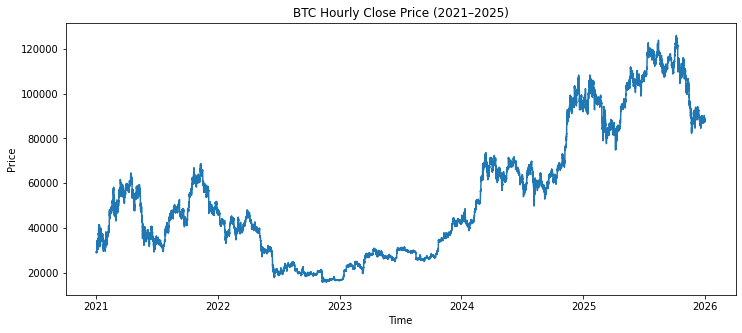

In [12]:
# Simple Visualisations
# Quick Sanity Check: Plotting Price Data over Time
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(btc_hourly['close'])
plt.title("BTC Hourly Close Price (2021–2025)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

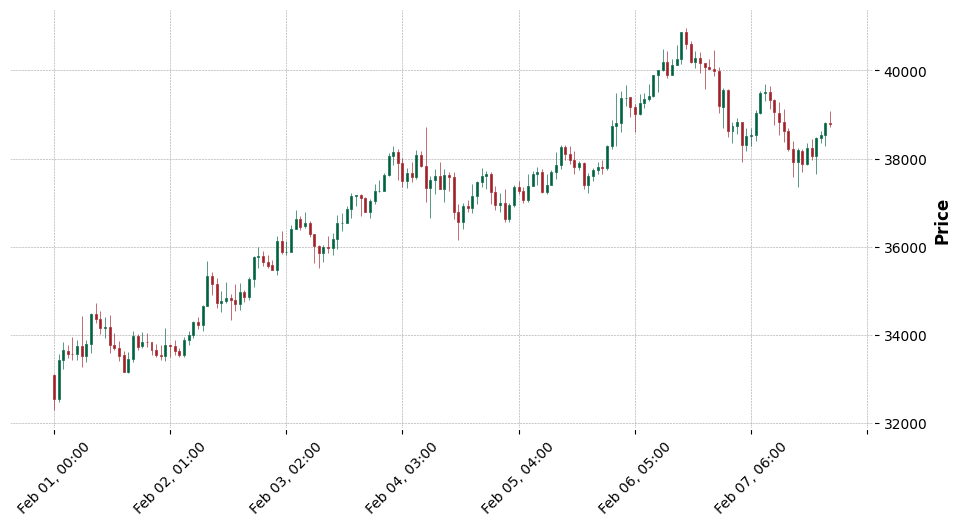

In [13]:
# 5 years worth of data for candlestick would be completely unreadable, let's start with a sample week
sample = btc_hourly.loc["2021-02-01":"2021-02-07"]

# using mplfinance for magnification
import mplfinance as mpf

mpf.plot(sample[['open','high','low','close','volume']],
         type='candle',
         volume=False,
         style='charles',
         figsize=(12,6))

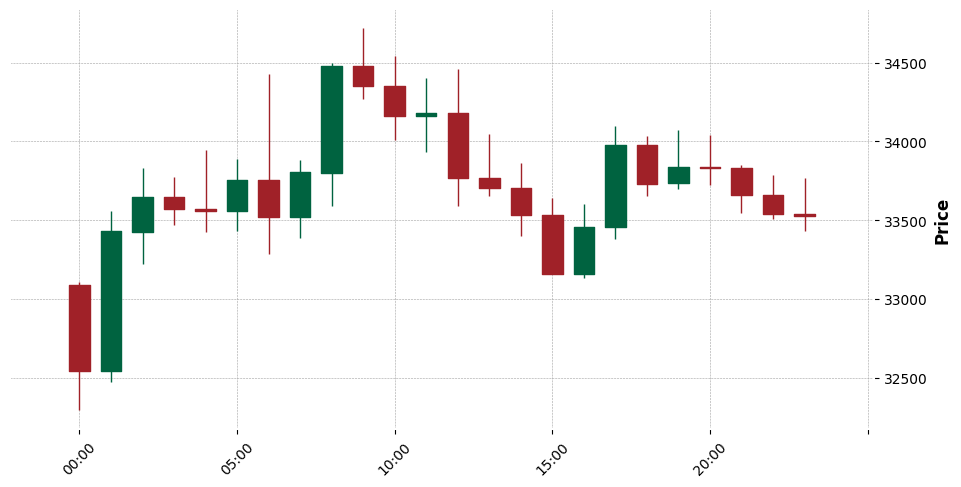

In [15]:
# let's move closer to say 4 days for our sample
sample_2 = btc_hourly.loc["2021-02-01":"2021-02-01"] 

mpf.plot(sample_2[['open','high','low','close','volume']],
         type='candle',
         volume=False,
         style='charles',
         figsize=(12,6))

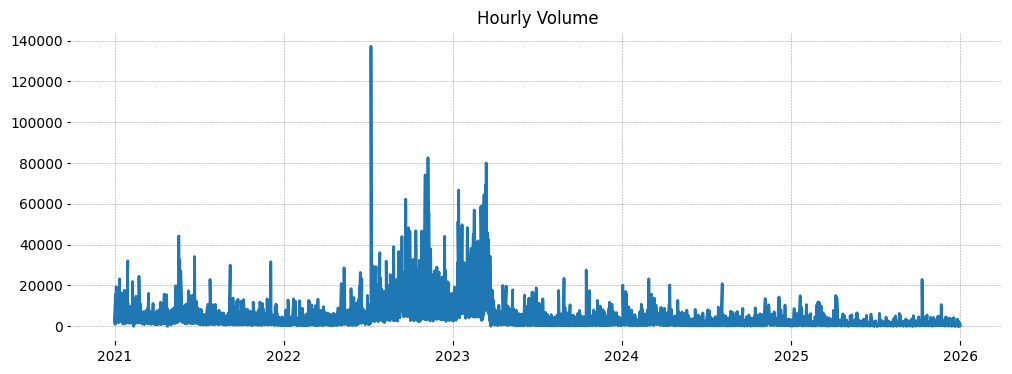

In [16]:
# Also a volume plot (for whole data) because volume anomalies often coincide with volatility spikes.
plt.figure(figsize=(12,4))
plt.plot(btc_hourly['volume'])
plt.title("Hourly Volume")
plt.show()

# there is no zero volume regions but we sure do see some volume (implying volatility) spikes

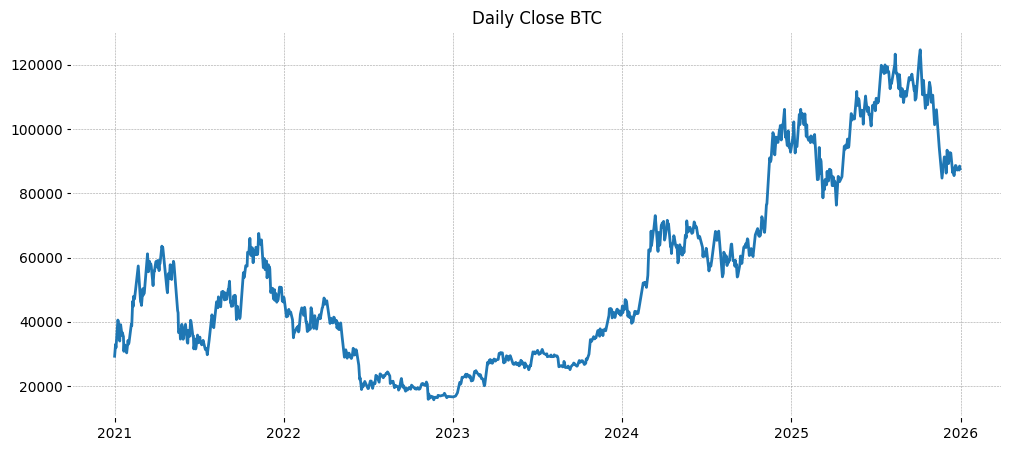

In [17]:
# Hourly across 5 years is a bit too high-freq
# Daily Resampled Close (to get a Cleaner Long-Term View)
daily_close = btc_hourly['close'].resample('D').last()

plt.figure(figsize=(12,5))
plt.plot(daily_close)
plt.title("Daily Close BTC")
plt.show()

# We are able to clearly see some macro trends we already know of eg: 2021 bull run, 2022 crash, 2023–2024 recovery

In [18]:
# quick desc stats
btc_hourly[['open','high','low','close','volume']].describe()

,open,high,low,close,volume
count,43810.000000,43810.000000,43810.000000,43810.000000,43810.000000
mean,54391.509041,54604.766811,54168.885718,54392.849889,3109.345521
std,29461.473509,29534.914622,29385.363820,29461.650867,4723.519487
min,15648.230000,15769.990000,15476.000000,15649.520000,0.000000
25%,29401.947500,29462.515000,29338.005000,29402.025000,750.329950
50%,46505.465000,46739.875000,46230.000000,46507.420000,1477.074660
75%,69059.915000,69269.387500,68807.530000,69064.160000,3338.380030
max,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600


In [ ]:
(btc_hourly['volume'] == 0).sum()
# earlier for 5-min data, we still had like 31, now since window is larger, much fewer

2

In [20]:
# Moving onto prelim construction of log returns
import numpy as np

btc_hourly['log_return'] = np.log(btc_hourly['close']).diff()
btc_hourly = btc_hourly.dropna(subset=['log_return'])

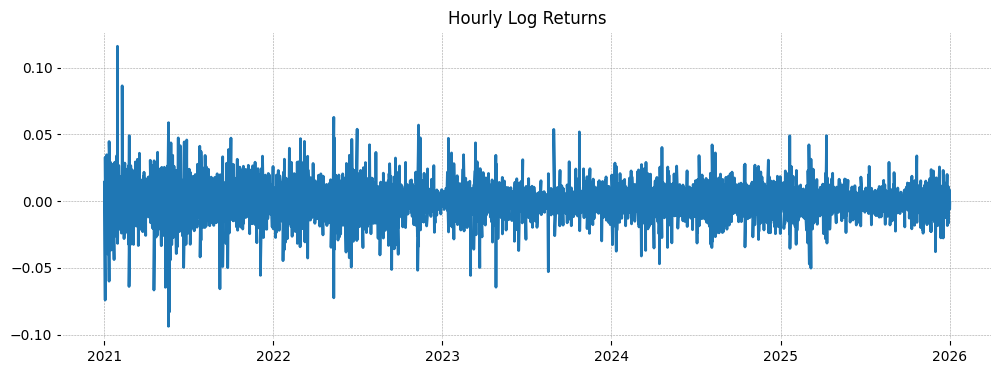

In [ ]:
# Plotting log returns
# Our expectation for log returns should be that they: look like white noise + volatility clustering + no trend
# we see more concentration compared to 5min data which again is expected
plt.figure(figsize=(12,4))
plt.plot(btc_hourly['log_return'])
plt.title("Hourly Log Returns")
plt.show()

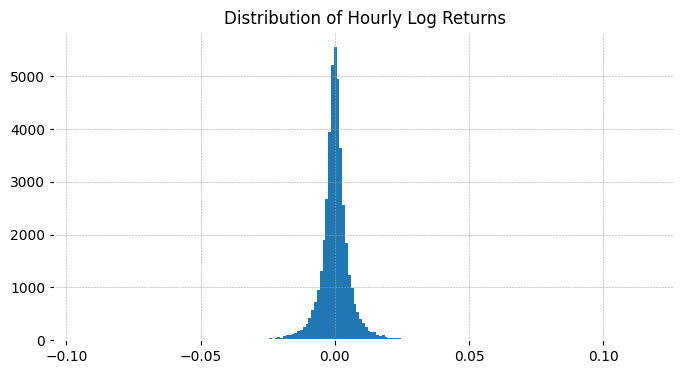

In [ ]:
# Now plotting the distribution of returns
plt.figure(figsize=(8,4))
plt.hist(btc_hourly['log_return'], bins=200)
plt.title("Distribution of Hourly Log Returns")
plt.show()

# # The log returns are highly concentrated near zero reflecting small incremental price changes at high frequency.
# The presence of fat tails suggests elevated kurtosis and a higher probability of extreme price movements, consistent with volatility clustering in BTC.

In [23]:
# numeric diagnosis
print(btc_hourly['log_return'].describe())
print(btc_hourly['log_return'].skew())
print(btc_hourly['log_return'].kurt())

count    43809.000000
mean         0.000025
std          0.006416
min         -0.093810
25%         -0.002321
50%          0.000046
75%          0.002477
max          0.116145
Name: log_return, dtype: float64
-0.20308496023522732
16.10614834776068


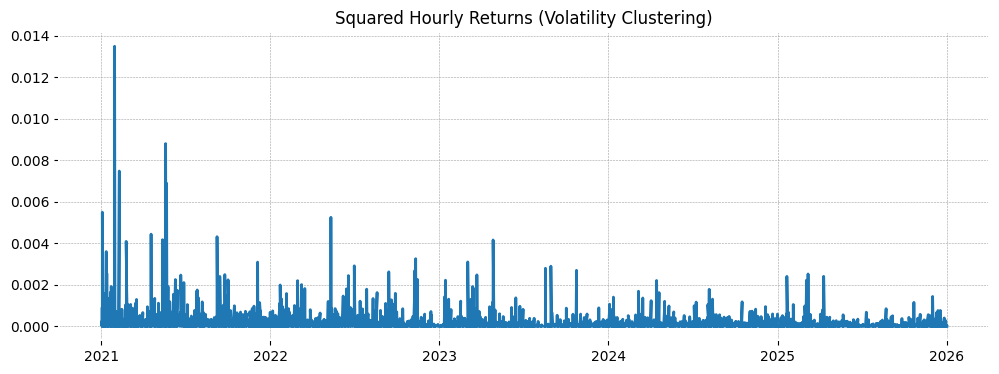

In [24]:
# Plotting squared returns
plt.figure(figsize=(12,4))
plt.plot(btc_hourly['log_return']**2)
plt.title("Squared Hourly Returns (Volatility Clustering)")
plt.show()

In [ ]:
# we can do ACFs after this if needed